<a href="https://colab.research.google.com/github/abhinav-sharma15/marketing-measurement-system/blob/main/notebooks/01_geo_lift_did_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
n_geos = 24
n_weeks = 12

geos = [f"Geo_{i+1}" for i in range(n_geos)]
weeks = np.arange(1, n_weeks + 1)

df = pd.MultiIndex.from_product(
    [geos, weeks],
    names=["geo", "week"]
).to_frame(index=False)

df.head()

,geo,week
0,Geo_1,1
1,Geo_1,2
2,Geo_1,3
3,Geo_1,4
4,Geo_1,5


In [3]:
treated_geos = np.random.choice(geos, size=n_geos // 2, replace=False)

df["treatment"] = df["geo"].isin(treated_geos).astype(int)
df["post_period"] = (df["week"] >= 7).astype(int)

df.head()

,geo,week,treatment,post_period
0,Geo_1,1,1,0
1,Geo_1,2,1,0
2,Geo_1,3,1,0
3,Geo_1,4,1,0
4,Geo_1,5,1,0


In [4]:
geo_baseline = {
    geo: np.random.normal(1000, 150)
    for geo in geos
}

df["geo_baseline"] = df["geo"].map(geo_baseline)

df["time_trend"] = df["week"] * 20

df["seasonality"] = 80 * np.sin(2 * np.pi * df["week"] / 12)

df["noise"] = np.random.normal(0, 80, size=len(df))

In [5]:
true_treatment_effect = 180

df["treatment_effect"] = (
    df["treatment"] *
    df["post_period"] *
    true_treatment_effect
)

In [6]:
df["revenue"] = (
    df["geo_baseline"]
    + df["time_trend"]
    + df["seasonality"]
    + df["treatment_effect"]
    + df["noise"]
)

df.head()

,geo,week,treatment,post_period,geo_baseline,time_trend,seasonality,noise,treatment_effect,revenue
0,Geo_1,1,1,0,1036.294341,20,40.000000,16.709088,0,1113.003428
1,Geo_1,2,1,0,1036.294341,40,69.282032,-156.773610,0,988.802763
2,Geo_1,3,1,0,1036.294341,60,80.000000,-106.254884,0,1070.039457
3,Geo_1,4,1,0,1036.294341,80,69.282032,15.748899,0,1201.325272
4,Geo_1,5,1,0,1036.294341,100,40.000000,59.077326,0,1235.371667


In [7]:
df.groupby("treatment")["geo"].nunique()

,geo
treatment,
0,12
1,12


In [8]:
df.groupby(["treatment", "post_period"])["revenue"].mean()

treatment  post_period
0          0              1084.772065
           1              1105.949743
1          0              1032.160138
           1              1254.718152
Name: revenue, dtype: float64

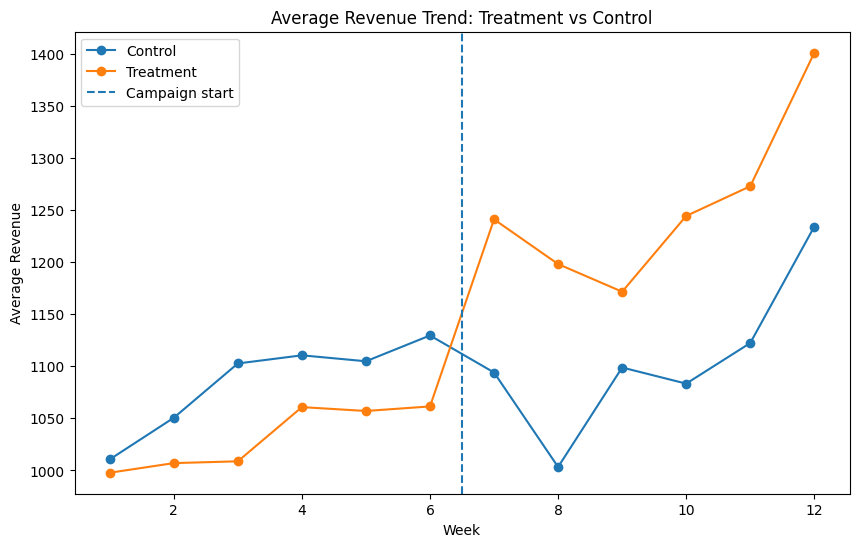

In [9]:
trend = (
    df.groupby(["week", "treatment"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for treatment_value, label in [(0, "Control"), (1, "Treatment")]:
    subset = trend[trend["treatment"] == treatment_value]
    plt.plot(subset["week"], subset["revenue"], marker="o", label=label)

plt.axvline(6.5, linestyle="--", label="Campaign start")
plt.title("Average Revenue Trend: Treatment vs Control")
plt.xlabel("Week")
plt.ylabel("Average Revenue")
plt.legend()
plt.show()

## Interpretation

This synthetic dataset represents a geo lift experiment.

- 24 geographies are observed over 12 weeks
- Half are assigned to treatment
- Treatment starts in week 7
- Revenue is affected by:
  - geo-level baseline demand
  - common time trend
  - seasonality
  - random noise
  - treatment effect

The goal is to estimate whether treated geos experienced additional growth after week 7 compared with control geos.

In [10]:
df["did_interaction"] = df["treatment"] * df["post_period"]

df[["geo", "week", "treatment", "post_period", "did_interaction", "revenue"]].head(10)

,geo,week,treatment,post_period,did_interaction,revenue
0,Geo_1,1,1,0,0,1113.003428
1,Geo_1,2,1,0,0,988.802763
2,Geo_1,3,1,0,0,1070.039457
3,Geo_1,4,1,0,0,1201.325272
4,Geo_1,5,1,0,0,1235.371667
5,Geo_1,6,1,0,0,1170.003803
6,Geo_1,7,1,1,1,1307.042478
7,Geo_1,8,1,1,1,1282.924013
8,Geo_1,9,1,1,1,1198.012582
9,Geo_1,10,1,1,1,1289.424772


In [11]:
did_table = (
    df.groupby(["treatment", "post_period"])["revenue"]
    .mean()
    .reset_index()
)

did_table

,treatment,post_period,revenue
0,0,0,1084.772065
1,0,1,1105.949743
2,1,0,1032.160138
3,1,1,1254.718152


In [12]:
did_pivot = did_table.pivot(
    index="treatment",
    columns="post_period",
    values="revenue"
)

did_pivot.columns = ["pre_period", "post_period"]
did_pivot.index = ["control", "treatment"]

did_pivot

,pre_period,post_period
control,1084.772065,1105.949743
treatment,1032.160138,1254.718152


In [13]:
control_change = did_pivot.loc["control", "post_period"] - did_pivot.loc["control", "pre_period"]
treatment_change = did_pivot.loc["treatment", "post_period"] - did_pivot.loc["treatment", "pre_period"]

manual_did = treatment_change - control_change

print(f"Control change: {control_change:.2f}")
print(f"Treatment change: {treatment_change:.2f}")
print(f"Manual DiD estimate: {manual_did:.2f}")

Control change: 21.18
Treatment change: 222.56
Manual DiD estimate: 201.38


The manual DiD estimate represents the additional post-period revenue growth in treatment geos compared with control geos.

Because the true simulated treatment effect was set to 180, the estimated DiD value should be reasonably close to 180, with some deviation due to noise.

In [14]:
import statsmodels.formula.api as smf

In [15]:
did_model = smf.ols(
    "revenue ~ treatment + post_period + did_interaction",
    data=df
).fit()

print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     24.93
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.39e-14
Time:                        10:29:43   Log-Likelihood:                -1872.1
No. Observations:                 288   AIC:                             3752.
Df Residuals:                     284   BIC:                             3767.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        1084.7721     19.107     

In [16]:
did_effect = did_model.params["did_interaction"]
did_pvalue = did_model.pvalues["did_interaction"]

print(f"Estimated DiD effect: {did_effect:.2f}")
print(f"P-value: {did_pvalue:.4f}")

Estimated DiD effect: 201.38
P-value: 0.0000


## Regression Interpretation

The DiD regression estimates the following relationship:

revenue = baseline + treatment_group_difference + post_period_change + treatment_post_effect

The key coefficient is `did_interaction`.

This coefficient estimates how much more revenue changed in treatment geos after the campaign compared with control geos.

If the coefficient is positive and statistically meaningful, it suggests the campaign generated incremental lift.

In [17]:
treatment_pre_mean = did_pivot.loc["treatment", "pre_period"]

lift_pct = did_effect / treatment_pre_mean

print(f"Treatment pre-period average revenue: {treatment_pre_mean:.2f}")
print(f"Incremental lift (%): {lift_pct:.2%}")

Treatment pre-period average revenue: 1032.16
Incremental lift (%): 19.51%


## Lift Interpretation

The estimated lift percentage compares the incremental revenue effect against the treatment group's pre-period baseline.

This helps translate the regression coefficient into a more business-friendly metric.

For example, if the estimated effect is 180 and the pre-period average revenue is 1,100, then the campaign produced roughly 16% incremental lift.

In [18]:
conf_int = did_model.conf_int().loc["did_interaction"]

print(f"95% confidence interval: [{conf_int[0]:.2f}, {conf_int[1]:.2f}]")

95% confidence interval: [126.16, 276.60]


## Confidence Interval

The confidence interval gives a plausible range for the incremental effect.

A narrow interval means the estimate is more precise.

A wide interval means there is more uncertainty, often due to:
- small sample size
- high noise
- weak treatment/control comparability

In [19]:
trend = (
    df.groupby(["week", "treatment"])["revenue"]
    .mean()
    .reset_index()
)

control_trend = trend[trend["treatment"] == 0].copy()
treatment_trend = trend[trend["treatment"] == 1].copy()

In [20]:
pre_treatment_gap = (
    treatment_trend[treatment_trend["week"] < 7]["revenue"].mean()
    - control_trend[control_trend["week"] < 7]["revenue"].mean()
)

treatment_counterfactual = control_trend.copy()
treatment_counterfactual["revenue"] = treatment_counterfactual["revenue"] + pre_treatment_gap

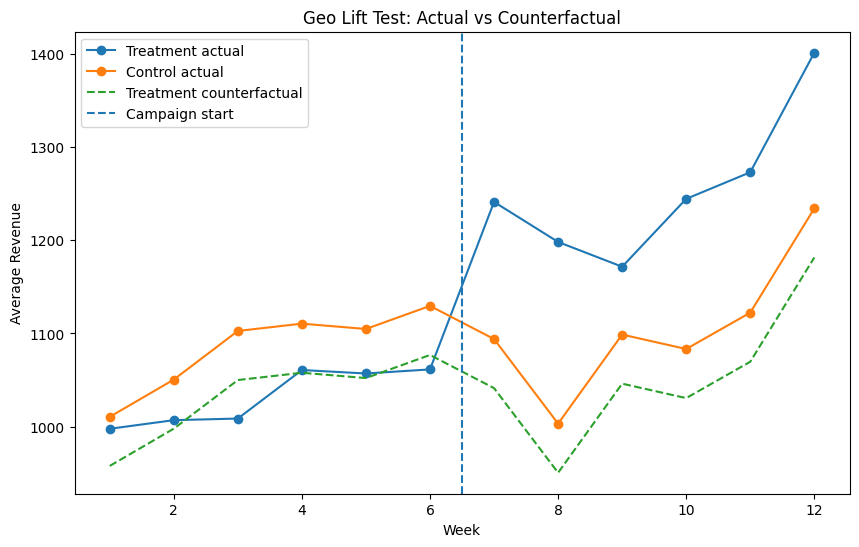

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    treatment_trend["week"],
    treatment_trend["revenue"],
    marker="o",
    label="Treatment actual"
)

plt.plot(
    control_trend["week"],
    control_trend["revenue"],
    marker="o",
    label="Control actual"
)

plt.plot(
    treatment_counterfactual["week"],
    treatment_counterfactual["revenue"],
    linestyle="--",
    label="Treatment counterfactual"
)

plt.axvline(6.5, linestyle="--", label="Campaign start")

plt.title("Geo Lift Test: Actual vs Counterfactual")
plt.xlabel("Week")
plt.ylabel("Average Revenue")
plt.legend()
plt.show()

## Counterfactual Interpretation

The dashed counterfactual line estimates how treatment geos may have performed without the campaign.

The gap between:
- treatment actual
- treatment counterfactual

after campaign launch represents estimated incremental lift.

# Business Readout

## Question

Did the campaign generate incremental revenue in treatment geos?

## Method

We used a Difference-in-Differences design comparing:
- treatment geos where the campaign was active
- control geos where the campaign was not active

before and after campaign launch.

## Result

The estimated incremental revenue lift was approximately:

[insert DiD estimate]

This corresponds to approximately:

[insert lift percentage]

relative to the treatment group baseline.

## Interpretation

The campaign appears to have generated incremental revenue beyond the growth observed in control geos.

## Assumptions

This interpretation relies on:
- treatment and control geos having similar pre-period trends
- no major spillovers across regions
- no external shocks affecting only one group
- stable campaign execution during the test

## Recommendation

If the estimate is positive and credible, the campaign should be considered for scaling.

However, before scaling, we should:
- validate pre-period trends
- check robustness
- run sensitivity tests
- monitor whether lift persists over time

In [22]:
summary = pd.DataFrame({
    "metric": [
        "Control pre/post change",
        "Treatment pre/post change",
        "Estimated incremental lift",
        "Estimated lift %",
        "P-value"
    ],
    "value": [
        control_change,
        treatment_change,
        did_effect,
        lift_pct,
        did_pvalue
    ]
})

summary

,metric,value
0,Control pre/post change,2.117768e+01
1,Treatment pre/post change,2.225580e+02
2,Estimated incremental lift,2.013803e+02
3,Estimated lift %,1.951057e-01
4,P-value,2.703791e-07


# Day 5: Diagnosing Bad Geo Lift Experiments

Difference-in-Differences relies heavily on the parallel trends assumption.

If treatment and control geos were already moving differently before the campaign, DiD may incorrectly attribute pre-existing momentum to marketing impact.

This is why good geo lift analysis must include:
- pre-period trend checks
- placebo tests
- sensitivity analysis
- business context validation

A statistically significant DiD estimate is not automatically credible.

In [23]:
df_bad = df.copy()

df_bad["hidden_treatment_trend"] = (
    df_bad["treatment"] *
    df_bad["week"] *
    25
)

df_bad["revenue_bad"] = (
    df_bad["geo_baseline"]
    + df_bad["time_trend"]
    + df_bad["seasonality"]
    + df_bad["hidden_treatment_trend"]
    + df_bad["treatment_effect"]
    + df_bad["noise"]
)

df_bad.head()

,geo,week,treatment,post_period,geo_baseline,time_trend,seasonality,noise,treatment_effect,revenue,did_interaction,hidden_treatment_trend,revenue_bad
0,Geo_1,1,1,0,1036.294341,20,40.000000,16.709088,0,1113.003428,0,25,1138.003428
1,Geo_1,2,1,0,1036.294341,40,69.282032,-156.773610,0,988.802763,0,50,1038.802763
2,Geo_1,3,1,0,1036.294341,60,80.000000,-106.254884,0,1070.039457,0,75,1145.039457
3,Geo_1,4,1,0,1036.294341,80,69.282032,15.748899,0,1201.325272,0,100,1301.325272
4,Geo_1,5,1,0,1036.294341,100,40.000000,59.077326,0,1235.371667,0,125,1360.371667


In this version, treatment geos have an additional upward trend even before the campaign starts.

This violates the parallel trends assumption.

If we ignore this and run DiD, the model may overestimate the campaign effect because it confuses pre-existing growth with incremental lift.

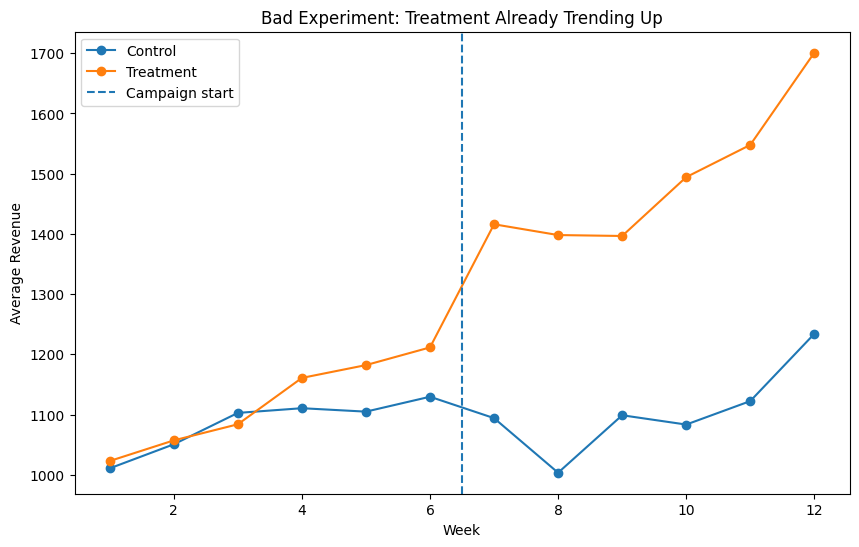

In [24]:
bad_trend = (
    df_bad.groupby(["week", "treatment"])["revenue_bad"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for treatment_value, label in [(0, "Control"), (1, "Treatment")]:
    subset = bad_trend[bad_trend["treatment"] == treatment_value]
    plt.plot(subset["week"], subset["revenue_bad"], marker="o", label=label)

plt.axvline(6.5, linestyle="--", label="Campaign start")
plt.title("Bad Experiment: Treatment Already Trending Up")
plt.xlabel("Week")
plt.ylabel("Average Revenue")
plt.legend()
plt.show()

In [25]:
bad_did_model = smf.ols(
    "revenue_bad ~ treatment + post_period + did_interaction",
    data=df_bad
).fit()

print(bad_did_model.summary())

                            OLS Regression Results                            
Dep. Variable:            revenue_bad   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     94.59
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.82e-42
Time:                        10:31:06   Log-Likelihood:                -1885.8
No. Observations:                 288   AIC:                             3780.
Df Residuals:                     284   BIC:                             3794.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        1084.7721     20.040     

In [26]:
bad_did_effect = bad_did_model.params["did_interaction"]
bad_did_pvalue = bad_did_model.pvalues["did_interaction"]

print(f"Bad DiD estimate: {bad_did_effect:.2f}")
print(f"True treatment effect: {true_treatment_effect:.2f}")
print(f"P-value: {bad_did_pvalue:.4f}")

Bad DiD estimate: 351.38
True treatment effect: 180.00
P-value: 0.0000


The bad DiD estimate is likely larger than the true simulated treatment effect.

This happens because the model attributes part of the pre-existing treatment trend to the campaign.

This demonstrates why DiD should never be interpreted without validating pre-period trends.

In [27]:
df_bad["fake_post_period"] = (df_bad["week"] >= 4).astype(int)
df_bad["fake_did_interaction"] = df_bad["treatment"] * df_bad["fake_post_period"]

placebo_df = df_bad[df_bad["week"] < 7].copy()

placebo_model = smf.ols(
    "revenue_bad ~ treatment + fake_post_period + fake_did_interaction",
    data=placebo_df
).fit()

print(placebo_model.summary())

                            OLS Regression Results                            
Dep. Variable:            revenue_bad   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     5.800
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           0.000913
Time:                        10:33:52   Log-Likelihood:                -927.94
No. Observations:                 144   AIC:                             1864.
Df Residuals:                     140   BIC:                             1876.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1054.6177 

In [28]:
placebo_effect = placebo_model.params["fake_did_interaction"]
placebo_pvalue = placebo_model.pvalues["fake_did_interaction"]

print(f"Placebo DiD estimate before campaign: {placebo_effect:.2f}")
print(f"Placebo p-value: {placebo_pvalue:.4f}")

Placebo DiD estimate before campaign: 69.91
Placebo p-value: 0.1764


A placebo test should ideally show no meaningful treatment effect before the campaign starts.

If we detect a strong “effect” before treatment, this suggests the treatment and control groups were already diverging.

That weakens the credibility of the main DiD estimate.

In [29]:
comparison = pd.DataFrame({
    "scenario": [
        "Good experiment",
        "Bad experiment with broken parallel trends",
        "Placebo pre-period test"
    ],
    "estimated_effect": [
        did_effect,
        bad_did_effect,
        placebo_effect
    ],
    "true_effect": [
        true_treatment_effect,
        true_treatment_effect,
        0
    ],
    "interpretation": [
        "Estimate should be close to true effect",
        "Estimate likely inflated by pre-existing trend",
        "Should be close to zero if assumptions hold"
    ]
})

comparison

,scenario,estimated_effect,true_effect,interpretation
0,Good experiment,201.380335,180,Estimate should be close to true effect
1,Bad experiment with broken parallel trends,351.380335,180,Estimate likely inflated by pre-existing trend
2,Placebo pre-period test,69.907328,0,Should be close to zero if assumptions hold


This comparison shows why diagnostics matter.

A DiD model can produce a clean-looking estimate even when the underlying experiment is flawed.

The analyst’s job is not only to run the regression, but to evaluate whether the comparison is credible.

In [30]:
pre_bad = df_bad[df_bad["post_period"] == 0].copy()

pretrend_model = smf.ols(
    "revenue_bad ~ treatment * week",
    data=pre_bad
).fit()

print(pretrend_model.summary())

                            OLS Regression Results                            
Dep. Variable:            revenue_bad   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     6.816
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           0.000254
Time:                        10:35:17   Log-Likelihood:                -926.56
No. Observations:                 144   AIC:                             1861.
Df Residuals:                     140   BIC:                             1873.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1008.2734     41.082     24.

In [31]:
pretrend_interaction = pretrend_model.params["treatment:week"]
pretrend_pvalue = pretrend_model.pvalues["treatment:week"]

print(f"Pre-period trend difference: {pretrend_interaction:.2f}")
print(f"P-value: {pretrend_pvalue:.4f}")

Pre-period trend difference: 18.01
P-value: 0.2295


The treatment-week interaction tests whether treatment geos had a different pre-period trend than control geos.

A meaningful positive value suggests treatment geos were already growing faster before the campaign.

This is a warning sign for DiD credibility.

# Geo Lift Diagnostic Checklist

Before trusting a DiD estimate, check:

## 1. Pre-Period Trend Similarity
Do treatment and control geos move similarly before the campaign?

## 2. Placebo Effects
Does the model detect fake lift before treatment starts?

## 3. Spillover Risk
Could control geos have been exposed indirectly?

## 4. External Shocks
Did competitors, pricing, sales activity, or market events affect one group differently?

## 5. Metric Stability
Is the outcome metric measured consistently across geos and time?

## 6. Business Plausibility
Is the estimated lift realistic given spend, channel, and historical performance?

## Key Takeaway

A DiD estimate is only as credible as the comparison behind it.

The goal is not simply to estimate lift.

The goal is to estimate lift that decision-makers can trust.

# Business Readout: Why This Bad Experiment Should Not Be Trusted

The bad experiment produced an inflated lift estimate because treatment geos were already growing faster before the campaign began.

This violates the parallel trends assumption.

Although the regression may show a positive and statistically significant result, the estimate is not fully credible.

Before making budget decisions, we should:
- improve geo matching
- extend the pre-period
- run placebo tests
- consider synthetic control
- validate results against business context

Recommendation:
Do not scale based only on this DiD result.

The experiment should be redesigned or supplemented with stronger methods.